# Lossless Audio Compression with Rice Coding

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ziadelh/media-compression-tools/blob/main/rice_coding_audio_compression.ipynb)

A lossless codec for WAV files built from scratch with **Rice coding**, a simple form of Golomb coding where the divisor is `M = 2^k`, so encoding needs only shifts and masks.

- **Encode:** WAV → delta predictor residuals → ZigZag → Rice → `SoundX_Enc.ex2`
- **Decode:** `.ex2` → Rice decode → inverse ZigZag → inverse predictor → `SoundX_Enc_Dec.wav`
- **Verify:** sample-level equality, to prove nothing was lost
- **Evaluate:** run with K = 2 and K = 4 on `Sound1.wav` and `Sound2.wav`, then explain why the two files behave so differently

## Setup

In [1]:
import os, subprocess

REPO_URL = "https://github.com/ziadelh/media-compression-tools.git"

# On Colab the repository is not on disk yet, so fetch it (the two WAV files are in data/sound/)
if not os.path.exists("data/sound/Sound1.wav"):
    if not os.path.exists("media-compression-tools"):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL], check=True)
    os.chdir("media-compression-tools")
os.makedirs("output/rice", exist_ok=True)
print("Ready.")

Ready.


In [2]:
# Imports

import struct, wave, os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Constants
EX2_MAGIC   = b'EX2\x00'
EX2_VERSION = 1

# Predictor IDs
PREDICTOR_NONE  = 0
PREDICTOR_DELTA = 1

## Bit level I/O "writer, reader"

Rice coding emits `unary(q)` + a `k`-bit remainder `r` per symbol. The bits are packed MSB first into bytes.

These two classes are the simple, one-bit-at-a-time version. They are easy to check by eye, so they serve as the **reference** that the faster version below is tested against.

In [3]:
# Bit level writer, reader for Rice coding

class BitWriter:
    def __init__(self):
        self.buf = bytearray()
        self.acc = 0
        self.nbits = 0

    def write_bits(self, v:int, n:int):
        # Write n bits of integer v "MSB first"
        for i in range(n-1, -1, -1):
            self.acc = (self.acc << 1) | ((v >> i) & 1)
            self.nbits += 1
            if self.nbits == 8:
                self.buf.append(self.acc & 0xFF)
                self.acc = 0
                self.nbits = 0

    def write_unary_ones_then_zero(self, q:int):
        # Write q ones followed by a zero
        while q >= 32:
            self.write_bits((1<<32)-1, 32)
            q -= 32
        if q > 0:
            self.write_bits((1<<q)-1, q)
        self.write_bits(0, 1)

    def finish(self) -> bytes:
        # Flush remaining bits
        if self.nbits:
            self.acc <<= (8 - self.nbits)
            self.buf.append(self.acc & 0xFF)
        return bytes(self.buf)


class BitReader:
    def __init__(self, data:bytes):
        self.data = data
        self.i = 0
        self.acc = 0
        self.nbits = 0

    def _pull(self):
        # Load next byte into buffer
        if self.i >= len(self.data):
            raise EOFError("End of stream")
        b = self.data[self.i]
        self.i += 1
        return b

    def read_bits(self, n:int) -> int:
        # Read n bits
        v = 0
        for _ in range(n):
            if self.nbits == 0:
                self.acc = self._pull()
                self.nbits = 8
            v = (v << 1) | ((self.acc >> 7) & 1)
            self.acc = (self.acc << 1) & 0xFF
            self.nbits -= 1
        return v

    def read_unary_ones_then_zero(self) -> int:
        # Read unary code q ones followed by zero
        q = 0
        while self.read_bits(1) == 1:
            q += 1
        return q

## ZigZag mapping and Rice core

Residuals are signed, so ZigZag maps them to non-negative integers (`0, -1, 1, -2, 2 ...` → `0, 1, 2, 3, 4 ...`), which suits Rice coding. Then values are encoded and decoded with a fixed `k` (so `M = 2^k`).

In [4]:
# ZigZag mapping and Rice encoder, decoder (reference implementation)

def signed_to_unsigned(x: np.ndarray) -> np.ndarray:
    # map signed residuals to non negative integers
    x = x.astype(np.int64)
    out = np.empty_like(x, dtype=np.uint32)
    pos = x >= 0
    out[pos]  = (2 * x[pos]).astype(np.uint32)
    out[~pos] = (-2 * x[~pos] - 1).astype(np.uint32)
    return out

def unsigned_to_signed(v: np.ndarray) -> np.ndarray:
    # recover signed residuals
    v = v.astype(np.int64)
    even = (v & 1) == 0
    out = np.empty_like(v, dtype=np.int64)
    out[even]  = v[even] // 2
    out[~even] = -((v[~even] + 1) // 2)
    return out.astype(np.int16)

def rice_encode_reference(arr: np.ndarray, k:int) -> bytes:
    # Rice encode array of unsigned ints with parameter k, one bit at a time
    m = 1 << k
    bw = BitWriter()
    mask = m - 1
    for val in arr.astype(np.uint32).ravel():
        q = int(val) >> k
        r = int(val) & mask
        bw.write_unary_ones_then_zero(q)
        if k:
            bw.write_bits(r, k)
    return bw.finish()

def rice_decode_reference(n_values:int, k:int, bitstream: bytes) -> np.ndarray:
    # Decode Rice coded stream back into unsigned ints, one bit at a time
    br = BitReader(bitstream)
    out = np.empty(n_values, dtype=np.uint32)
    for i in range(n_values):
        q = br.read_unary_ones_then_zero()
        r = br.read_bits(k) if k else 0
        out[i] = (q << k) | r
    return out

## A faster codec with identical output

The reference code handles every bit in a Python loop. That is fine for a short clip, but `Sound2.wav` at K = 2 produces about 1.8 billion bits, which would take the better part of an hour.

The fast version produces **exactly the same bytes**:

- **Encoding** works on blocks of values with NumPy. It marks the run of ones of every unary code, writes the `k` remainder bits, and packs the bits into bytes, carrying the unfinished byte from one block to the next.
- **Decoding** reads 64 bits at a time and uses the bit length of the inverted word to count the run of ones in one step, instead of testing one bit per loop.

The next cell checks that both versions agree.

In [5]:
def rice_encode_unsigned(arr: np.ndarray, k:int, block:int = 4096) -> bytes:
    # Rice encode with NumPy, same bitstream as rice_encode_reference
    arr = np.asarray(arr, dtype=np.uint64).ravel()
    mask = (1 << k) - 1
    out = bytearray()
    carry = np.zeros(0, dtype=np.uint8)           # bits of the unfinished byte
    for start in range(0, len(arr), block):
        v = arr[start:start + block]
        q = (v >> np.uint64(k)).astype(np.int64)
        n = q + 1 + k                              # bits used by each value: q ones, a zero, k remainder bits
        ends = np.cumsum(n)
        starts = ends - n
        total = int(ends[-1])

        # the unary part: q ones starting at starts[i] (marked with a difference array)
        diff = np.zeros(total + 1, dtype=np.int8)
        diff[starts] += 1
        diff[starts + q] -= 1
        bits = np.cumsum(diff[:-1], dtype=np.int8).astype(np.uint8)

        # the k remainder bits, most significant first
        r = (v & np.uint64(mask)).astype(np.int64)
        for j in range(k):
            bits[starts + q + 1 + j] = (r >> (k - 1 - j)) & 1

        bits = np.concatenate([carry, bits])
        whole = (len(bits) // 8) * 8
        out += np.packbits(bits[:whole]).tobytes()
        carry = bits[whole:]
    if len(carry):
        out += np.packbits(carry).tobytes()        # pads the last byte with zeros, like BitWriter.finish()
    return bytes(out)

def rice_decode_unsigned(n_values:int, k:int, bitstream: bytes) -> np.ndarray:
    # Decode Rice coded stream with 64-bit lookups, same result as rice_decode_reference
    data = bitstream
    total_bits = len(data) * 8
    ALL = (1 << 64) - 1
    kmask = (1 << k) - 1
    out = np.empty(n_values, dtype=np.uint32)
    pos = 0
    for i in range(n_values):
        q = 0
        while True:
            if pos >= total_bits:
                raise EOFError("End of stream")
            b = pos >> 3
            word = int.from_bytes(data[b:b + 9].ljust(9, b"\x00"), "big")
            w = (word >> (8 - (pos & 7))) & ALL      # the next 64 bits
            inverted = ~w & ALL
            if inverted:                             # a zero bit ends the unary code
                ones = 64 - inverted.bit_length()
                q += ones
                pos += ones + 1
                break
            q += 64
            pos += 64
        r = 0
        if k:
            if pos + k > total_bits:
                raise EOFError("End of stream")
            b = pos >> 3
            word = int.from_bytes(data[b:b + 9].ljust(9, b"\x00"), "big")
            r = (word >> (72 - (pos & 7) - k)) & kmask
            pos += k
        out[i] = (q << k) | r
    return out

In [6]:
# Check that the fast codec matches the reference on real audio (the first 20,000 residuals of both files)
def predict_for_test(path):
    with wave.open(str(path), 'rb') as wf:
        a = np.frombuffer(wf.readframes(wf.getnframes()), dtype=np.int16).astype(np.int32)
    return signed_to_unsigned(np.diff(a, prepend=0).astype(np.int16))[:20000]

for name in ["Sound1.wav", "Sound2.wav"]:
    sample = predict_for_test(Path("data/sound") / name)
    for k in (2, 4):
        same_bytes = rice_encode_unsigned(sample, k) == rice_encode_reference(sample, k)
        stream = rice_encode_reference(sample, k)
        same_values = np.array_equal(rice_decode_unsigned(len(sample), k, stream), rice_decode_reference(len(sample), k, stream))
        print(f"{name} K={k}: encoded bytes identical = {same_bytes}, decoded values identical = {same_values}")

Sound1.wav K=2: encoded bytes identical = True, decoded values identical = True


Sound1.wav K=4: encoded bytes identical = True, decoded values identical = True


Sound2.wav K=2: encoded bytes identical = True, decoded values identical = True


Sound2.wav K=4: encoded bytes identical = True, decoded values identical = True


## WAV I/O and predictor

A delta (order-1) predictor works per channel: `r[0] = x[0]`, `r[n] = x[n] - x[n-1]`. The inverse is a cumulative sum. Audio changes smoothly from one sample to the next, so the differences are much smaller than the samples themselves, and small numbers are what Rice coding is good at.

In [7]:
# WAV read, write and delta predictor

def read_wav_int16(path: Path):
    # Read WAV file and return samples and metadata
    with wave.open(str(path), 'rb') as wf:
        ch, sw, fr, nf = wf.getnchannels(), wf.getsampwidth(), wf.getframerate(), wf.getnframes()
        raw = wf.readframes(nf)
    assert sw == 2, f"Only PCM16 supported; got sampwidth={sw}"
    a = np.frombuffer(raw, dtype=np.int16).copy()
    if ch > 1:
        a = a.reshape(-1, ch)
    return a, ch, sw, fr, nf

def write_wav_int16(path: Path, a: np.ndarray, ch:int, sw:int, fr:int):
    # Write samples back to a WAV file
    data = a.astype(np.int16).ravel().tobytes()
    with wave.open(str(path), 'wb') as wf:
        wf.setnchannels(ch)
        wf.setsampwidth(sw)
        wf.setframerate(fr)
        wf.writeframes(data)

def predict_residuals(a: np.ndarray) -> np.ndarray:
    if a.ndim == 1:
        r = np.empty_like(a, dtype=np.int16)
        r[0] = a[0]
        r[1:] = (a[1:].astype(np.int32) - a[:-1].astype(np.int32)).astype(np.int16)
    else:
        r = np.empty_like(a, dtype=np.int16)
        r[0,:] = a[0,:]
        r[1:,:] = (a[1:,:].astype(np.int32) - a[:-1,:].astype(np.int32)).astype(np.int16)
    return r

def invert_residuals(r: np.ndarray) -> np.ndarray:
    if r.ndim == 1:
        x = r.astype(np.int32); np.cumsum(x, out=x); return x.astype(np.int16)
    x = r.astype(np.int32); np.cumsum(x, axis=0, out=x); return x.astype(np.int16)

## EX2 container format

The `.ex2` file is a 24-byte header (magic, version, `k`, predictor id, channels, bits per sample, sample rate, frame count, payload length) followed by the Rice-coded payload, so a file can be decoded without knowing anything else about it.

In [8]:
# EX2 container write, read

def write_ex2(path: Path, *, k:int, predictor_id:int, ch:int, sw:int, fr:int, nf:int, payload:bytes):
    # Write .ex2 file
    header = struct.pack("<4sBBBHHIII",
                         EX2_MAGIC, EX2_VERSION, k, predictor_id, ch, sw*8, fr, nf, len(payload))
    with open(path, "wb") as f:
        f.write(header)
        f.write(payload)

def read_ex2(path: Path):
    # Read .ex2 file and return header fields and payload
    with open(path, "rb") as f:
        header = f.read(struct.calcsize("<4sBBBHHIII"))
        magic, ver, k, predictor_id, ch, sampbits, fr, nf, plen = struct.unpack("<4sBBBHHIII", header)
        assert magic == EX2_MAGIC and ver == EX2_VERSION
        payload = f.read(plen)
    return {
        "k": k,
        "predictor_id": predictor_id,
        "ch": ch,
        "sw": sampbits // 8,
        "fr": fr,
        "nf": nf,
        "payload": payload
    }

## End to end codec

- `encode_wav_to_ex2`: WAV → EX2 using the delta predictor and Rice coding
- `decode_ex2_to_wav`: EX2 → WAV
- `wavs_equal`: the verification helper that compares the samples and the metadata

In [9]:
# End to end encode, decode, and verification

def encode_wav_to_ex2(in_path: Path, out_path: Path, k:int) -> int:
    # Encode WAV into .ex2 format with Rice coding
    a, ch, sw, fr, nf = read_wav_int16(in_path)
    r = predict_residuals(a)
    mapped = signed_to_unsigned(r.ravel())
    payload = rice_encode_unsigned(mapped, k)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    write_ex2(out_path, k=k, predictor_id=PREDICTOR_DELTA,
              ch=ch, sw=sw, fr=fr, nf=nf, payload=payload)
    return struct.calcsize("<4sBBBHHIII") + len(payload)

def decode_ex2_to_wav(in_path: Path, out_path: Path):
    # Decode .ex2 file back into WAV
    meta = read_ex2(in_path)
    k, ch, sw, fr, nf, payload = meta["k"], meta["ch"], meta["sw"], meta["fr"], meta["nf"], meta["payload"]
    nvals = nf * ch
    unsigned_vals = rice_decode_unsigned(nvals, k, payload)
    residuals = unsigned_to_signed(unsigned_vals).astype(np.int16)
    if ch > 1:
        residuals = residuals.reshape(nf, ch)
    recon = invert_residuals(residuals)
    write_wav_int16(out_path, recon, ch, sw, fr)

def wavs_equal(a_path: Path, b_path: Path) -> bool:
    # Check if two wavs have identical PCM data and metadata
    a, ch_a, sw_a, fr_a, nf_a = read_wav_int16(a_path)
    b, ch_b, sw_b, fr_b, nf_b = read_wav_int16(b_path)
    return (ch_a, sw_a, fr_a, nf_a) == (ch_b, sw_b, fr_b, nf_b) and np.array_equal(a, b)

## Run on Sound1.wav and Sound2.wav with K = 2 and K = 4

For each file and each `k` this encodes to `SoundX_Enc_kK.ex2`, decodes to `SoundX_Enc_kK_Dec.wav`, checks that the samples are identical and records the sizes. A negative compression means the "compressed" file is larger than the original.

In [10]:
# Encode, Decode Sound1 and Sound2, build results table

base = Path("data/sound")
out_dir = Path("output/rice")
inputs = [
    base / "Sound1.wav",
    base / "Sound2.wav"
]
ks = [2, 4]

rows = []
for wav in inputs:
    assert wav.exists(), f"Missing {wav}"
    orig_size = os.path.getsize(wav)
    row = {"File": wav.name, "Original size (bytes)": orig_size}
    for k in ks:
        enc = out_dir / (wav.stem + f"_Enc_k{k}.ex2")
        dec = out_dir / (wav.stem + f"_Enc_k{k}_Dec.wav")
        ex2_size = encode_wav_to_ex2(wav, enc, k=k)
        decode_ex2_to_wav(enc, dec)
        ok = wavs_equal(wav, dec)
        assert ok, f"Round-trip failed for {wav.name} at K={k}"
        row[f"Rice (K={k}) size (bytes)"] = ex2_size
        row[f"Recovered OK (K={k})"] = ok
    rows.append(row)

df = pd.DataFrame(rows)
for k in ks:
    df[f"% Compression (K={k})"] = (1 - df[f"Rice (K={k}) size (bytes)"]/df["Original size (bytes)"])*100.0

os.makedirs("results", exist_ok=True)
df.to_csv("results/rice_compression.csv", index=False)
display(df.round(2))

,File,Original size (bytes),Rice (K=2) size (bytes),Recovered OK (K=2),Rice (K=4) size (bytes),Recovered OK (K=4),% Compression (K=2),% Compression (K=4)
0,Sound1.wav,1002088,2429928,True,857474,True,-142.49,14.43
1,Sound2.wav,1008044,224816527,True,56448286,True,-22202.25,-5499.78


## Why do the two files compress so differently?

A Rice code spends `q + 1 + k` bits on a value `v`, where `q = v >> k`. If the residuals are small, a small `k` is cheap. If they are large, `q` becomes a long run of ones and the code explodes, because the unary part grows in proportion to the value divided by `2^k`. The best `k` is therefore tied to the typical size of the residuals: roughly `log2` of their mean.

The size of the file for every `k` can be computed directly from the residuals, without encoding anything.

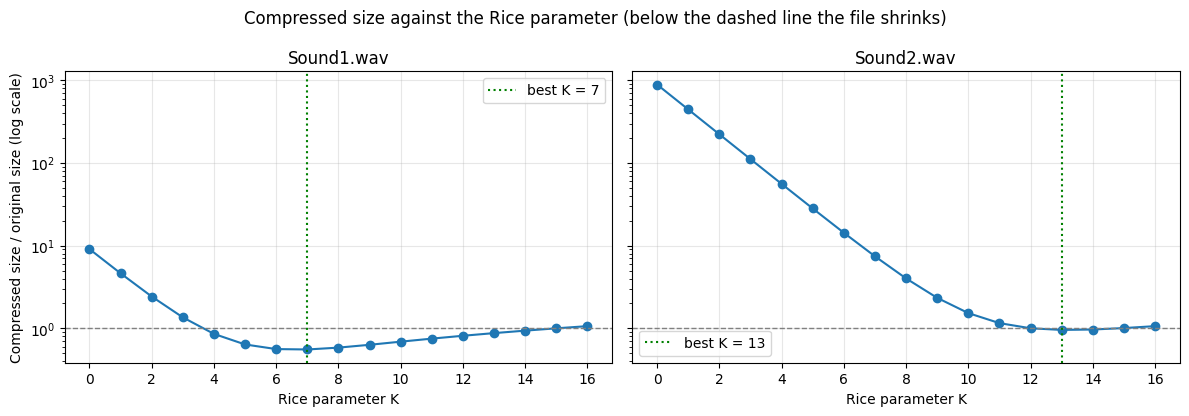

,File,Mean |residual|,Best K,Size at best K (bytes),% Compression at best K
0,Sound1.wav,72.5,7,555614,44.6
1,Sound2.wav,7132.0,13,964009,4.4


In [11]:
def size_in_bytes(mapped, k, header=struct.calcsize("<4sBBBHHIII")):
    # exact Rice size: sum of (q + 1 + k) bits plus the header
    return int((np.sum(mapped >> k) + len(mapped) * (1 + k) + 7) // 8) + header

summary = []
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
for ax, wav in zip(axes, inputs):
    a, ch, sw, fr, nf = read_wav_int16(wav)
    mapped = signed_to_unsigned(predict_residuals(a).ravel()).astype(np.int64)
    original = os.path.getsize(wav)
    k_range = list(range(0, 17))
    ratio = [size_in_bytes(mapped, k) / original for k in k_range]
    best_k = k_range[int(np.argmin(ratio))]

    ax.plot(k_range, ratio, marker="o")
    ax.axhline(1.0, color="grey", linestyle="--", linewidth=1)
    ax.axvline(best_k, color="green", linestyle=":", label=f"best K = {best_k}")
    ax.set_yscale("log")
    ax.set_title(f"{wav.name}")
    ax.set_xlabel("Rice parameter K")
    ax.grid(True, alpha=0.3)
    ax.legend()
    summary.append({"File": wav.name,
                    "Mean |residual|": round(float(np.mean(np.abs(predict_residuals(a).astype(np.int64)))), 1),
                    "Best K": best_k,
                    "Size at best K (bytes)": size_in_bytes(mapped, best_k),
                    "% Compression at best K": round((1 - size_in_bytes(mapped, best_k) / original) * 100, 1)})
axes[0].set_ylabel("Compressed size / original size (log scale)")
fig.suptitle("Compressed size against the Rice parameter (below the dashed line the file shrinks)")
plt.tight_layout()
os.makedirs("docs", exist_ok=True)
plt.savefig("docs/rice-size-vs-k.png", dpi=110)
plt.show()
pd.DataFrame(summary)